# Formativa 2 — Modelamiento Predictivo (práctica)
**MCDI501 · Grupo 4 · Bank Marketing UCI**

Práctica formativa (0 %) que prepara la Sumativa 3. Construida explícitamente sobre los resultados de S1 y S2.

In [1]:
# §§0 — Configuración global
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_curve, roc_auc_score, ConfusionMatrixDisplay)

from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False})

# Detección dinámica de la raíz del proyecto
raiz = Path().resolve()
for _ in range(5):
    if (raiz / 'data').exists():
        break
    raiz = raiz.parent
RUTA_CSV = raiz / 'data' / 'raw' / 'bank-additional' / 'bank-additional-full.csv'

df = pd.read_csv(RUTA_CSV, sep=';')
df['y_bin'] = (df['y'] == 'yes').astype(int)
print(f'Dataset cargado: {df.shape}')
print(f'Tasa de suscripción: {df["y_bin"].mean():.4f} '
      f'({df["y_bin"].sum():,} yes / {(df["y_bin"]==0).sum():,} no)')


Dataset cargado: (41188, 22)
Tasa de suscripción: 0.1127 (4,640 yes / 36,548 no)


## §1 — Preparación de datos para modelamiento

### 1.1 Hallazgos relevantes de S1 y S2

**Sumativa 1 — resultados clave:**

| Análisis | Resultado | Implicancia |
|---|---|---|
| IC 95 % `age` | [39.92, 40.12] | Estimador robusto, efecto pequeño (d=0.096) |
| IC 95 % `euribor3m` | [3.60, 3.64] | Variable macroeconómica estable |
| IC 95 % `nr.employed` | [5166.3, 5167.7] | Alta multicolinealidad con `euribor3m` |
| Prueba t edad (yes vs no) | p=1.80×10⁻⁶, d=0.096 | Significativa pero efecto pequeño |
| Chi² `poutcome` vs `y` | V Cramér=0.32 | Efecto grande — **feature de alta prioridad** |
| Desbalance de clases | 88.7 % no / 11.3 % yes | Usar F1 y AUC-ROC como métricas principales |

**Sumativa 2 — correlaciones validadas (IC bootstrap 95 %, 10.000 remuestras):**

| Par | r medio | IC 95 % | Estabilidad |
|---|---|---|---|
| `euribor3m` vs `nr.employed` | 0.945 | [0.944, 0.946] | Alta multicolinealidad — elegir una |
| `euribor3m` vs `emp.var.rate` | 0.972 | [0.972, 0.973] | Alta multicolinealidad — excluir |
| `euribor3m` vs `y_bin` | −0.308 | [−0.318, −0.298] | **Robusta, usar en modelo** |
| `previous` vs `y_bin` | 0.230 | [0.216, 0.245] | **Robusta, usar en modelo** |
| `age` vs `y_bin` | 0.031 | [0.018, 0.043] | Significativa, magnitud baja |

**Outliers (S2 §5):** `age`: 469 obs. (1.14 %) fuera de [9.5, 69.5] años (Tukey). Sin influyentes en `euribor3m` ni `nr.employed` (jackknife LOO).

**Restricciones metodológicas:**
- `duration` excluida — proxy post-hoc del target (data leakage)
- Usar solo una entre `euribor3m`, `emp.var.rate`, `nr.employed` (r > 0.94)
- `pdays=999` recodificar a binaria (contactado / no contactado)

In [2]:
# §1.2 — Revisión de valores faltantes y unknowns
print('=== Valores NaN reales ===')
nans = df.isnull().sum()
print(nans[nans > 0].to_string() if nans.any() else 'Ninguno')

print('\n=== Frecuencia de unknown por variable categórica ===')
cat_cols = df.select_dtypes(include='object').columns.drop('y')
unk = {c: (df[c] == 'unknown').sum() for c in cat_cols if (df[c] == 'unknown').any()}
for col, n in sorted(unk.items(), key=lambda x: -x[1]):
    print(f'  {col:20s}: {n:5,} ({n/len(df)*100:.1f}%)')


=== Valores NaN reales ===
Ninguno

=== Frecuencia de unknown por variable categórica ===
  default             : 8,597 (20.9%)
  education           : 1,731 (4.2%)
  housing             :   990 (2.4%)
  loan                :   990 (2.4%)
  job                 :   330 (0.8%)
  marital             :    80 (0.2%)


### 1.2 Estrategia de tratamiento de datos

**Valores NaN:** no existen NaN reales (confirmado en S1).

**Valores "unknown":** se conservan como categoría propia. Eliminar filas reduciría el dataset ~22 % e introduciría sesgo de selección; además, el unknown puede ser informativo (clientes que no revelan datos podrían tener un perfil específico).

**Outliers en `age`:** se conservan. Su eliminación invierte el signo del estadístico t (S2 §5.2), lo que indica que representan un subgrupo real y no errores de medición.

**Variable `pdays`:** recodificada a binaria `contactado_previo` (1 si pdays ≠ 999, 0 si pdays = 999). El 96.3 % tiene pdays=999 y la tasa de suscripción difiere drásticamente: 63.83 % vs 9.26 %.

In [3]:
# §1.3 — Ingeniería de variables y selección de features
df_model = df.copy()

# Recodificar pdays -> contactado_previo
df_model['contactado_previo'] = (df_model['pdays'] != 999).astype(int)
print(f'contactado_previo=1: {df_model["contactado_previo"].sum():,} '
      f'({df_model["contactado_previo"].mean()*100:.1f}%)')
print(f'  Tasa suscripción contactados:    '
      f'{df_model[df_model["contactado_previo"]==1]["y_bin"].mean()*100:.1f}%')
print(f'  Tasa suscripción no contactados: '
      f'{df_model[df_model["contactado_previo"]==0]["y_bin"].mean()*100:.1f}%')

# poutcome ordinal: nonexistent=0, failure=1, success=2
poutcome_map = {'nonexistent': 0, 'failure': 1, 'success': 2}
df_model['poutcome_enc'] = df_model['poutcome'].map(poutcome_map)

# Features seleccionadas y justificadas en S1 y S2
FEATURES = [
    'euribor3m',        # r=-0.308 con y_bin, IC bootstrap robusto (S2)
    'poutcome_enc',     # V Cramér=0.32 vs y — mayor efecto en S1
    'previous',         # r=0.230 con y_bin, IC robusto (S2)
    'age',              # prueba t significativa (S1), efecto pequeño
    'contactado_previo' # pdays recodificado; tasa 63.8% vs 9.3%
]

X = df_model[FEATURES]
y_target = df_model['y_bin']

print(f'\nFeatures: {FEATURES}')
print(f'Shape X: {X.shape}')
print('\nEstadísticos básicos:')
print(X.describe().round(3).to_string())


contactado_previo=1: 1,515 (3.7%)
  Tasa suscripción contactados:    63.8%
  Tasa suscripción no contactados: 9.3%

Features: ['euribor3m', 'poutcome_enc', 'previous', 'age', 'contactado_previo']
Shape X: (41188, 5)

Estadísticos básicos:
       euribor3m  poutcome_enc   previous        age  contactado_previo
count  41188.000     41188.000  41188.000  41188.000          41188.000
mean       3.621         0.170      0.173     40.024              0.037
std        1.734         0.456      0.495     10.421              0.188
min        0.634         0.000      0.000     17.000              0.000
25%        1.344         0.000      0.000     32.000              0.000
50%        4.857         0.000      0.000     38.000              0.000
75%        4.961         0.000      0.000     47.000              0.000
max        5.045         2.000      7.000     98.000              1.000


In [4]:
# §1.4 — División train/test (70/30, estratificada)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_target, test_size=0.30, random_state=SEED, stratify=y_target)

print(f'Train: {X_train.shape[0]:,} obs. | Test: {X_test.shape[0]:,} obs.')
print(f'Tasa y=1 train: {y_train.mean():.4f} | Tasa y=1 test: {y_test.mean():.4f}')
print('Estratificación mantiene el desbalance original en ambos subconjuntos.')


Train: 28,831 obs. | Test: 12,357 obs.
Tasa y=1 train: 0.1127 | Tasa y=1 test: 0.1126
Estratificación mantiene el desbalance original en ambos subconjuntos.


In [5]:
# §1.5 — Estandarización de variables numéricas continuas
# poutcome_enc y contactado_previo son ordinal/binaria -> no se estandarizan
NUM_FEATURES = ['euribor3m', 'previous', 'age']
BIN_FEATURES = ['poutcome_enc', 'contactado_previo']

scaler = StandardScaler()
X_train_sc = X_train.copy()
X_test_sc  = X_test.copy()

X_train_sc[NUM_FEATURES] = scaler.fit_transform(X_train[NUM_FEATURES])
X_test_sc[NUM_FEATURES]  = scaler.transform(X_test[NUM_FEATURES])

print('Variables estandarizadas (media≈0, std≈1 en train):')
print(X_train_sc[NUM_FEATURES].describe().round(3).to_string())
print('\nVariables ordinales/binarias (sin estandarizar):')
print(X_train_sc[BIN_FEATURES].describe().round(3).to_string())


Variables estandarizadas (media≈0, std≈1 en train):
       euribor3m   previous        age
count  28831.000  28831.000  28831.000
mean       0.000      0.000     -0.000
std        1.000      1.000      1.000
min       -1.720     -0.351     -2.214
25%       -1.311     -0.351     -0.771
50%        0.713     -0.351     -0.194
75%        0.773     -0.351      0.672
max        0.821     13.598      5.579

Variables ordinales/binarias (sin estandarizar):
       poutcome_enc  contactado_previo
count     28831.000          28831.000
mean          0.173              0.038
std           0.460              0.191
min           0.000              0.000
25%           0.000              0.000
50%           0.000              0.000
75%           0.000              0.000
max           2.000              1.000


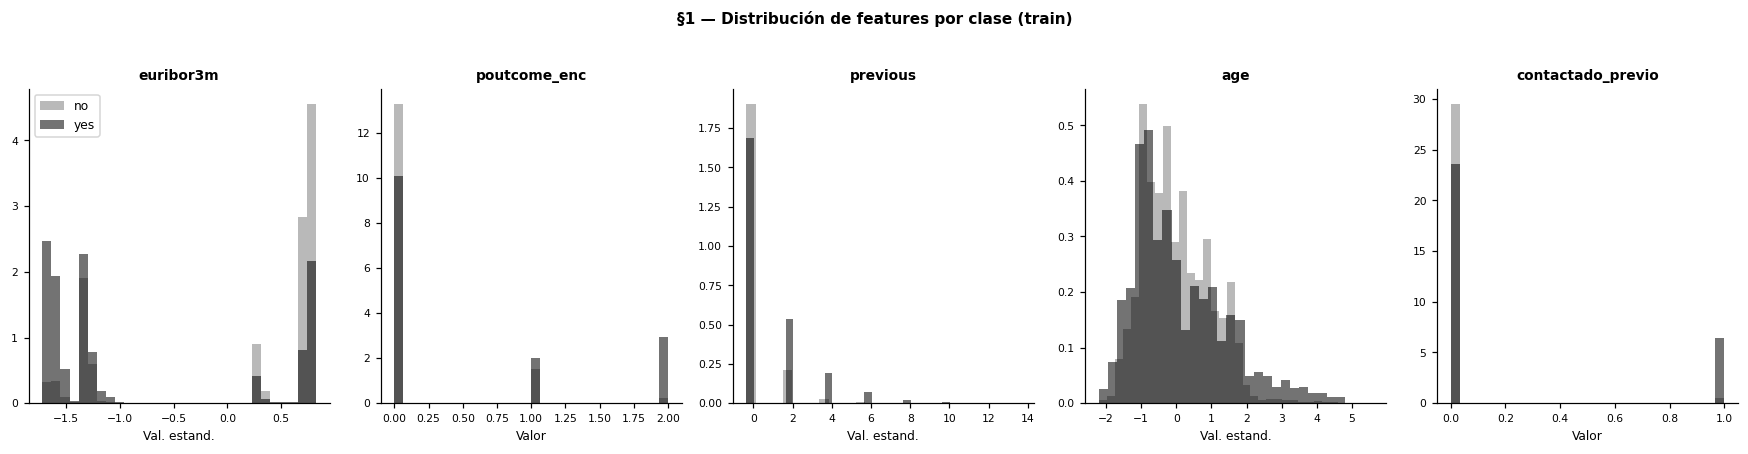

In [6]:
# §1.6 — Distribución de features por clase (train)
fig, axes = plt.subplots(1, 5, figsize=(16, 4))
for ax, feat in zip(axes, FEATURES):
    vals_no  = X_train_sc[feat][y_train == 0]
    vals_yes = X_train_sc[feat][y_train == 1]
    ax.hist(vals_no,  bins=30, alpha=0.55, label='no',  color='gray',  density=True)
    ax.hist(vals_yes, bins=30, alpha=0.55, label='yes', color='black', density=True)
    ax.set_title(feat, fontsize=9, fontweight='bold')
    ax.set_xlabel('Val. estand.' if feat in NUM_FEATURES else 'Valor', fontsize=8)
    ax.tick_params(labelsize=7)
    if feat == FEATURES[0]:
        ax.legend(fontsize=8)
fig.suptitle('§1 — Distribución de features por clase (train)',
             fontsize=10, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### 1.3 Resumen de preparación

| Decisión | Elección | Justificación |
|---|---|---|
| Valores NaN | Sin tratamiento | No existen NaN reales (S1) |
| Valores unknown | Conservar como categoría | Bajo porcentaje; potencialmente informativos |
| Outliers `age` | Conservar | Subgrupo real; eliminación invierte signo t (S2 §5.2) |
| `duration` | Excluida | Proxy post-hoc del target — data leakage |
| `pdays` | Binaria `contactado_previo` | 96.3 % = 999; tasa 63.8 % vs 9.3 % |
| Split | 70 % train / 30 % test estratificado | Mantiene desbalance 88.7 %/11.3 % |
| Estandarización | Solo `euribor3m`, `previous`, `age` | Ordinales/binarias no requieren escala |
| Features | `euribor3m`, `poutcome_enc`, `previous`, `age`, `contactado_previo` | Validadas en S1 y S2; sin multicolinealidad severa |

**Objetos disponibles para §2:** `X_train_sc`, `X_test_sc`, `y_train`, `y_test`, `FEATURES`, `NUM_FEATURES`, `BIN_FEATURES`, `scaler`.

## Sección 2 - Modelo de regresión logística

Modelo predictivo sobre las features seleccionadas y justificadas en S1

### 2.1 Modelo de regresión logística (scikit-learn)

**Nota:** Por defecto, LogisticRegression aplica regularización, lo que encoge los coeficientes. Fijamos C muy alto para dejarla prácticamente nula y así aproximar la estimación por máxima verosimilitud. De este modo, los coeficientes de sklearn quedan directamente comparables con los de statsmodels que se verá en la siguiente subsección 2.2.

In [7]:
modelo_logistico = LogisticRegression(C=1e9, solver='lbfgs', max_iter=5000, random_state=SEED)
modelo_logistico.fit(X_train_sc, y_train)

intercepto_modelo = modelo_logistico.intercept_[0]
coeficientes_modelo = pd.Series(modelo_logistico.coef_[0], index= FEATURES)

print('Modelo ajustado sobre X_train_sc / y_train')
print(f'  Observaciones de entrenamiento : {X_train_sc.shape[0]:,}')
print(f'  Número de predictores          : {len(FEATURES)}')
print(f'  Iteraciones hasta converger    : {modelo_logistico.n_iter_[0]}')

print(f'\nIntercepto (log-odds): {intercepto_modelo:+.4f}')
print('Coeficientes (escala log-odds):')
for nombre_predictor in FEATURES:
    print(f'  {nombre_predictor:18s}: {coeficientes_modelo[nombre_predictor]:+.4f}')

Modelo ajustado sobre X_train_sc / y_train
  Observaciones de entrenamiento : 28,831
  Número de predictores          : 5
  Iteraciones hasta converger    : 17

Intercepto (log-odds): -2.4389
Coeficientes (escala log-odds):
  euribor3m         : -0.8034
  poutcome_enc      : -0.3876
  previous          : -0.0038
  age               : +0.0706
  contactado_previo : +2.4934


### 2.2 Resumen estadístico del modelo con statsmodels

**Nota:** statsmodels ajusta el modelo por máxima verosimilitud y entrega los p-valores, errores estándar e intervalos de confianza de los coeficientes. Esta información de inferencia es la que scikit-learn no reporta y la que permite evaluar la significancia de cada predictor.

In [8]:
X_train_con_constante = sm.add_constant(X_train_sc)
modelo_statsmodels    = sm.Logit(y_train, X_train_con_constante)
resultado_regresion   = modelo_statsmodels.fit(disp=False)

print(resultado_regresion.summary())

# Comprobación de consistencia: los coeficientes de ambas librerías deben coincidir
print('\nComparación de coeficientes sklearn vs statsmodels:')
print(f'{"Predictor":18s} {"sklearn":>10s} {"statsmodels":>12s} {"|dif|":>10s}')
for nombre_predictor in FEATURES:
    coef_sklearn     = coeficientes_modelo[nombre_predictor]
    coef_statsmodels = resultado_regresion.params[nombre_predictor]
    diferencia       = abs(coef_sklearn - coef_statsmodels)
    print(f'{nombre_predictor:18s} {coef_sklearn:10.4f} '
          f'{coef_statsmodels:12.4f} {diferencia:10.6f}')

                           Logit Regression Results                           
Dep. Variable:                  y_bin   No. Observations:                28831
Model:                          Logit   Df Residuals:                    28825
Method:                           MLE   Df Model:                            5
Date:                Thu, 09 Jul 2026   Pseudo R-squ.:                  0.1609
Time:                        22:27:54   Log-Likelihood:                -8516.5
converged:                       True   LL-Null:                       -10149.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -2.4391      0.027    -91.803      0.000      -2.491      -2.387
euribor3m            -0.8035      0.022    -37.061      0.000      -0.846      -0.761
poutcome_enc         -0.

2.3 Odds Ratios (exp del coeficiente) e intervalos de confianza (95%)

El odds ratio (exp(coef)) indica cuánto cambian los odds de suscripción (y=1) cuando el predictor aumenta en una unidad y el resto se mantiene constante:
OR > 1 → los odds aumentan (el predictor favorece la suscripción).
OR < 1 → los odds disminuyen.
OR = 1 → el predictor no influye.

In [9]:
coeficientes_regresion = resultado_regresion.params
intervalos_confianza   = resultado_regresion.conf_int()
intervalos_confianza.columns = ['ic_inferior', 'ic_superior']

tabla_odds_ratios = pd.DataFrame({
    'coeficiente'   : coeficientes_regresion,
    'odds_ratio'    : np.exp(coeficientes_regresion),
    'or_ic_inferior': np.exp(intervalos_confianza['ic_inferior']),
    'or_ic_superior': np.exp(intervalos_confianza['ic_superior']),
    'p_valor'       : resultado_regresion.pvalues,
})
tabla_odds_ratios = tabla_odds_ratios.drop(index='const')   # el intercepto no se interpreta como OR

print('Odds ratios por predictor:')
print(tabla_odds_ratios.round(4).to_string())

print('\nInterpretación (por cada +1 desviación estándar / +1 unidad):')
for nombre_predictor in FEATURES:
    odds_ratio = tabla_odds_ratios.loc[nombre_predictor, 'odds_ratio']
    if odds_ratio > 1:
        variacion = f'aumentan un {(odds_ratio - 1) * 100:5.1f}%'
    else:
        variacion = f'disminuyen un {(1 - odds_ratio) * 100:5.1f}%'
    print(f'  {nombre_predictor:18s} OR={odds_ratio:6.3f}  ->  '
          f'los odds de suscripción {variacion}')

Odds ratios por predictor:
                   coeficiente  odds_ratio  or_ic_inferior  or_ic_superior  p_valor
euribor3m              -0.8035      0.4478          0.4291          0.4672   0.0000
poutcome_enc           -0.3872      0.6789          0.5810          0.7934   0.0000
previous               -0.0038      0.9962          0.9454          1.0497   0.8861
age                     0.0705      1.0730          1.0361          1.1113   0.0001
contactado_previo       2.4928     12.0954          9.5191         15.3689   0.0000

Interpretación (por cada +1 desviación estándar / +1 unidad):
  euribor3m          OR= 0.448  ->  los odds de suscripción disminuyen un  55.2%
  poutcome_enc       OR= 0.679  ->  los odds de suscripción disminuyen un  32.1%
  previous           OR= 0.996  ->  los odds de suscripción disminuyen un   0.4%
  age                OR= 1.073  ->  los odds de suscripción aumentan un   7.3%
  contactado_previo  OR=12.095  ->  los odds de suscripción aumentan un 1109.5%


### 2.4 Significancia estadística de cada variable (umbral p < 0.05)

**Nota:** El p_valor indica la probabilidad de observar el efecto de una variable si en realidad no influyera sobre la suscripción (hipótesis nula: coeficiente = 0). Comparamos cada p-valor con el nivel de significancia (0.05).

Si:

p < 0.05 → la variable es estadísticamente significativa por lo que rechazamos la hipótesis nula y consideramos que su efecto es real.
p ≥ 0.05 → no significativa señala que no hay evidencia suficiente para afirmar que influye.

In [10]:
UMBRAL_SIGNIFICANCIA = 0.05

variables_significativas    = []
variables_no_significativas = []

print(f'Evaluación de significancia (alfa = {UMBRAL_SIGNIFICANCIA}):\n')
print(f'{"Predictor":18s} {"p-valor":>12s} {"Significativa":>14s}')
for nombre_predictor in FEATURES:
    p_valor = resultado_regresion.pvalues[nombre_predictor]
    es_significativa = p_valor < UMBRAL_SIGNIFICANCIA
    etiqueta = 'Sí' if es_significativa else 'No'
    print(f'{nombre_predictor:18s} {p_valor:12.2e} {etiqueta:>14s}')
    if es_significativa:
        variables_significativas.append(nombre_predictor)
    else:
        variables_no_significativas.append(nombre_predictor)

print(f'\nSignificativas ({len(variables_significativas)}): '
      f'{variables_significativas}')
print(f'No significativas ({len(variables_no_significativas)}): '
      f'{variables_no_significativas}')

Evaluación de significancia (alfa = 0.05):

Predictor               p-valor  Significativa
euribor3m             1.19e-300             Sí
poutcome_enc           1.12e-06             Sí
previous               8.86e-01             No
age                    8.14e-05             Sí
contactado_previo      1.74e-92             Sí

Significativas (4): ['euribor3m', 'poutcome_enc', 'age', 'contactado_previo']
No significativas (1): ['previous']


### 2.5 Factor de inflación de la varianza (VIF)
Acá se mide cuánto se infla la varianza del coeficiente de un predictor por su correlación con los demás.

**Nota:** Un VIF alto avisa de multicolinealidad: coeficientes inestables y difíciles de interpretar.

In [11]:
X_para_vif = sm.add_constant(X_train_sc)

filas_vif = []
for indice_columna in range(X_para_vif.shape[1]):
    nombre_columna = X_para_vif.columns[indice_columna]
    if nombre_columna == 'const':
        continue
    valor_vif = variance_inflation_factor(X_para_vif.values, indice_columna)
    filas_vif.append({'feature': nombre_columna, 'vif': valor_vif})

tabla_vif = pd.DataFrame(filas_vif).sort_values('vif', ascending=False)

print('VIF por feature:')
print(tabla_vif.round(3).to_string(index=False))

print('\nRegla de interpretación habitual:')
print('VIF < 5 -> sin multicolinealidad preocupante')
print('5 <= VIF <10 -> multicolinealidad moderada')
print('VIF >= 10 -> multicolinealidad severa')

VIF por feature:
          feature   vif
     poutcome_enc 6.303
         previous 4.131
contactado_previo 2.347
        euribor3m 1.329
              age 1.001

Regla de interpretación habitual:
VIF < 5 -> sin multicolinealidad preocupante
5 <= VIF <10 -> multicolinealidad moderada
VIF >= 10 -> multicolinealidad severa


### 2.6 Diagnóstico de multicolinealidad



In [12]:
VIF_MODERADO = 5
VIF_SEVERO   = 10

vif_maximo          = tabla_vif['vif'].max()
feature_vif_maximo  = tabla_vif.iloc[0]['feature']

print(f'VIF máximo observado: {vif_maximo:.3f}  (feature: {feature_vif_maximo})\n')
if vif_maximo >= VIF_SEVERO:
    print('CONCLUSIÓN: multicolinealidad SEVERA -> revisar o eliminar predictores.')
elif vif_maximo >= VIF_MODERADO:
    print('CONCLUSIÓN: multicolinealidad MODERADA -> vigilar la estabilidad de los coeficientes.')
else:
    print('CONCLUSIÓN: NO se detecta multicolinealidad relevante entre las features.')

VIF máximo observado: 6.303  (feature: poutcome_enc)

CONCLUSIÓN: multicolinealidad MODERADA -> vigilar la estabilidad de los coeficientes.


**Observación del VIF**: Cuatro de las cinco features tienen VIF < 5, sin multicolinealidad preocupante. La excepción es poutcome_enc (VIF = 6.30), que cae en el rango de multicolinealidad moderada (5 ≤ VIF < 10), seguida por previous (4.13). Esto tiene sentido ya que ambas variables recogen el historial de campañas previas, por lo que comparten información.
Ninguna variable alcanza el umbral de multicolinealidad severa (VIF ≥ 10). 

**Conclusión:** no hay un problema grave, solo conviene vigilar la estabilidad de los coeficientes de poutcome_enc y previous.

## Sección 3 — Evaluación del desempeño predictivo

### Objetivo

En esta sección se evalúa la capacidad predictiva del modelo de regresión logística ajustado en la Sección 2. Para ello se analizan distintas métricas de clasificación y la curva ROC, con especial énfasis en el desbalance presente en la variable objetivo.

In [13]:
y_pred = modelo_logistico.predict(X_test_sc)
y_prob = modelo_logistico.predict_proba(X_test_sc)[:, 1]

print(f'Observaciones de prueba: {len(y_test):,}')
print(f'Predicciones generadas : {len(y_pred):,}')

Observaciones de prueba: 12,357
Predicciones generadas : 12,357


### 3.1 Matriz de confusión

La matriz de confusión permite evaluar el desempeño del modelo comparando las clases reales con las predicciones realizadas sobre el conjunto de prueba. Esta herramienta resume los aciertos y errores de clasificación, distinguiendo entre verdaderos positivos, verdaderos negativos, falsos positivos y falsos negativos.

Su análisis resulta especialmente relevante en este problema debido al desbalance de clases, ya que un modelo puede obtener una alta exactitud clasificando correctamente la mayoría de los casos negativos, sin necesariamente identificar adecuadamente a los clientes que sí suscriben un depósito a plazo.

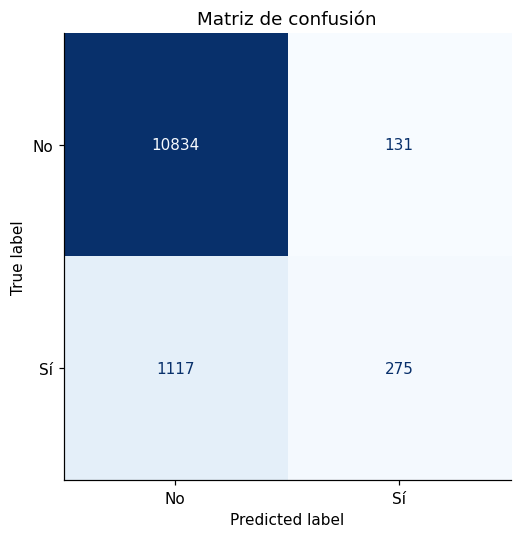

In [14]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(5, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["No", "Sí"],
    cmap="Blues",
    colorbar=False,
    ax=ax
)

ax.set_title("Matriz de confusión")
plt.tight_layout()
plt.show()

### Interpretación

La matriz de confusión muestra que el modelo clasifica correctamente la gran mayoría de los clientes que **no suscriben** un depósito a plazo, con 10.834 verdaderos negativos y solo 131 falsos positivos.

Sin embargo, el desempeño sobre la clase positiva es más limitado: de los clientes que efectivamente suscribieron, el modelo identifica correctamente 275 casos, mientras que 1.117 son clasificados incorrectamente como "No". Este comportamiento es consistente con el desbalance del conjunto de datos, donde la clase negativa representa la mayor parte de las observaciones.

Por ello, además de la exactitud (accuracy), resulta necesario analizar métricas como **precision**, **recall** y **F1-score**, ya que entregan una evaluación más completa de la capacidad del modelo para detectar la clase minoritaria.

In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

metricas = pd.DataFrame({
    "Métrica": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Valor": [accuracy, precision, recall, f1]
})

metricas["Valor"] = metricas["Valor"].round(4)
metricas

,Métrica,Valor
0,Accuracy,0.8990
1,Precision,0.6773
2,Recall,0.1976
3,F1-score,0.3059


### 3.2 Métricas de desempeño

Las métricas de clasificación permiten evaluar el desempeño del modelo desde distintas perspectivas. En problemas con clases desbalanceadas, como el presente caso, la exactitud (accuracy) por sí sola puede resultar insuficiente, ya que una alta proporción de casos pertenece a la clase "No".

Por este motivo también se analizan **precision**, **recall** y **F1-score**, métricas que permiten evaluar la capacidad del modelo para identificar correctamente a los clientes que sí suscriben un depósito a plazo.

### Interpretación

El modelo obtiene una **accuracy de 89,9 %**, lo que indica que clasifica correctamente la mayoría de las observaciones. Sin embargo, esta métrica debe interpretarse con cautela debido al desbalance del conjunto de datos, donde la mayoría de los clientes no suscribe un depósito a plazo.

La **precision de 67,7 %** muestra que, cuando el modelo predice que un cliente suscribirá el producto, aproximadamente dos de cada tres predicciones son correctas.

En contraste, el **recall de 19,8 %** evidencia que el modelo identifica solo una fracción de los clientes que realmente suscriben un depósito, dejando sin detectar un número importante de casos positivos.

Como consecuencia, el **F1-score de 30,6 %** refleja un desempeño moderado sobre la clase minoritaria, indicando que aún existe margen de mejora para aumentar la capacidad predictiva del modelo sin incrementar excesivamente los falsos positivos.

### Interpretación

El modelo obtiene una **accuracy de 89,9 %**, lo que indica que clasifica correctamente la mayoría de las observaciones. Sin embargo, esta métrica debe interpretarse con cautela debido al desbalance del conjunto de datos, donde la mayoría de los clientes no suscribe un depósito a plazo.

La **precision de 67,7 %** muestra que, cuando el modelo predice que un cliente suscribirá el producto, aproximadamente dos de cada tres predicciones son correctas.

En contraste, el **recall de 19,8 %** evidencia que el modelo identifica solo una fracción de los clientes que realmente suscriben un depósito, dejando sin detectar un número importante de casos positivos.

Como consecuencia, el **F1-score de 30,6 %** refleja un desempeño moderado sobre la clase minoritaria, indicando que aún existe margen de mejora para aumentar la capacidad predictiva del modelo sin incrementar excesivamente los falsos positivos.

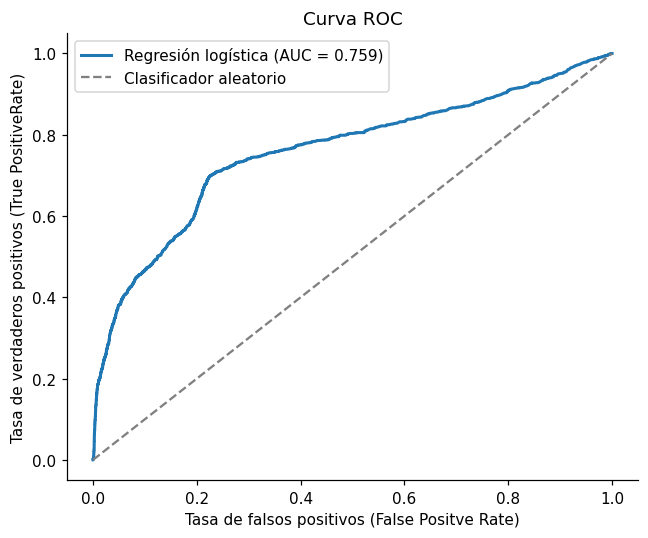

AUC: 0.7588


In [17]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6, 5))

plt.plot(fpr, tpr, linewidth=2,
         label=f"Regresión logística (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1],
         linestyle="--",
         color="gray",
         label="Clasificador aleatorio")

plt.xlabel("Tasa de falsos positivos (False Positve Rate)")
plt.ylabel("Tasa de verdaderos positivos (True PositiveRate)")
plt.title("Curva ROC")
plt.legend()

plt.tight_layout()
plt.show()

print(f"AUC: {auc:.4f}")

### Interpretación

El modelo obtuvo un **AUC de 0,759**, valor que corresponde a un desempeño **aceptable** según los criterios establecidos para la evaluación de clasificadores.

Este resultado indica que el modelo posee una capacidad razonable para distinguir entre clientes que suscriben y aquellos que no lo hacen, superando ampliamente el comportamiento de un clasificador aleatorio (AUC = 0,5).

No obstante, el AUC debe interpretarse junto con las demás métricas obtenidas. Si bien el modelo discrimina adecuadamente entre ambas clases, el bajo **recall** evidencia que aún presenta dificultades para identificar una proporción importante de clientes que efectivamente suscriben un depósito a plazo. En consecuencia, futuras mejoras podrían orientarse al tratamiento del desbalance de clases o al ajuste del umbral de decisión para incrementar la detección de casos positivos.